# Notebook 34 — The $(\alpha,\beta_r)$ banana: is it also in System I, and what does it mean?

**Trigger.** Section 8.1 of the manuscript ("Artefact 2") reports that System II's
reactor-side pair $(\alpha,\beta_r)$ has a posterior correlation of **+0.998** at
scenario W11 ($\alpha=\beta_r=0.80$) under the 66-D summary representation — the
strongest confound in the whole $5\times5$ Fisher information matrix. System I's
catalyst/jacket pair $(\alpha,\beta)$ looks, on paper, like the same problem: both
are multiplicative degradation factors on the same two physical mechanisms
(reaction rate, jacket heat transfer), masked by the same PI integral-control
mechanism (Section 7.3, `sec:identifiability`).

**Questions this notebook answers.**
1. Does System I show the same near-degenerate $(\alpha,\beta)$ banana? (Short
   answer, checked below against both a trained posterior and a fresh local FIM:
   **no** — the correlation is small, under either representation.)
2. Why the difference, mechanistically? (Checked via the paper's own
   raw-trajectory-FIM (RT-FIM) methodology, generalised to a *channel-ablation*
   experiment: strip System I's reactor-composition channel and see if the
   banana reappears; conversely, add a reactor-composition channel to System II
   and see if it collapses.)
3. What does this imply for identifiability of **failure modes** (coarse,
   unit-level fault diagnosis) versus **parameters** (fine-grained attribution
   within a unit)?

All FIM machinery is imported unchanged from `scripts/fim_utils.py` (the same
module `notebooks/33_fim_cross_system_validation.ipynb` uses), and the System
I/II simulator wrappers below are copied from that notebook's matched-protocol
warm-start fix, so every number here is directly comparable to the manuscript's
own Section 8.1 figures.


## 1. Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT / "scripts"))

import jax
import jax.numpy as jnp

jax.config.update("jax_enable_x64", True)

from fim_utils import compute_fim, offdiag_ratio, cov_offdiag_corr, crb_report

RESULTS = ROOT / "results"
FIGS = ROOT / "figures"
FIGS.mkdir(exist_ok=True)

np.set_printoptions(precision=4, suppress=True)


## 2. Does a trained posterior show the banana in System I?

System I's production identifiability study
(`notebooks/system_I/08_identifiability_and_saturation.ipynb`) already pooled the
M6 posterior samples for every scenario and reported `Corr(alpha, beta)` for the
two scenarios where both parameters are simultaneously degraded: Sc4 (combined,
non-saturating) and Sc5 (severe fouling, actuator-saturating). We reuse that
cached array directly rather than retraining, since it is the same posterior the
manuscript's Table `tab:scenario_results` reports.

In [2]:
d_m6 = np.load(RESULTS / "sbi_posteriors_m6.npz", allow_pickle=False)
samples_m6 = d_m6["samples"]       # (400, 1000, 2) = (replicate, draw, [alpha, beta])
scenario_id = d_m6["scenario_id"]

SC_TRUE = {4: (0.85, 0.85), 5: (1.00, 0.40)}
SC_NOTE = {4: "combined, non-saturating", 5: "severe fouling, actuator-saturating"}

print(f"{'Scenario':10s} {'alpha*':>7s} {'beta*':>7s} {'pooled Corr(a,b)':>18s}   note")
corr_sys1 = {}
for sid, (a_t, b_t) in SC_TRUE.items():
    mask = scenario_id == sid
    pooled = samples_m6[mask].reshape(-1, 2)
    c = np.corrcoef(pooled[:, 0], pooled[:, 1])[0, 1]
    corr_sys1[sid] = c
    print(f"Sc{sid:<9d} {a_t:7.2f} {b_t:7.2f} {c:18.3f}   {SC_NOTE[sid]}")

print()
print("Compare to System II, W11 (alpha=beta_r=0.80) -- reproduced live below from the")
print("actual trained S-B posterior, not just quoted from the manuscript.")


Scenario    alpha*   beta*   pooled Corr(a,b)   note
Sc4            0.85    0.85             -0.341   combined, non-saturating
Sc5            1.00    0.40              0.471   severe fouling, actuator-saturating

Compare to System II, W11 (alpha=beta_r=0.80) -- reproduced live below from the
actual trained S-B posterior, not just quoted from the manuscript.


To make the System II number in this comparison just as directly reproduced as
the System I one above (not merely quoted from the manuscript), we load the
production S-B posterior and sample it at a fresh W11 observation.

In [3]:
import pickle
import torch

from cstr_sbi.recycle.scenarios import get_scenario
from cstr_sbi.recycle.simulator import nominal_warm_start
from cstr_sbi.recycle.physics import (
    NOMINAL_CTRL_SB, NOMINAL_INLET, extract_observations_explicit,
    simulate_trajectory_explicit_jit, PARAM_NAMES,
)
from cstr_sbi.recycle.summaries import compute_summaries

SBI_LOGS = ROOT / "sbi-logs"
with open(SBI_LOGS / "wu2003_posterior_sb.pkl", "rb") as f:
    posterior_sb = pickle.load(f)["posterior"]

sc_w11 = get_scenario("W11_reactor_combined")
theta_w11 = np.asarray(sc_w11.theta())
y0_w11 = nominal_warm_start("S-B")
ts_w11, ys_w11 = simulate_trajectory_explicit_jit(
    jnp.array(theta_w11), NOMINAL_INLET, NOMINAL_CTRL_SB, jnp.array(y0_w11),
    t_final=2.0, n_save=120, rtol=1e-3, atol=1e-5,
)
raw_w11 = np.asarray(extract_observations_explicit(ys_w11, jnp.array(theta_w11), NOMINAL_CTRL_SB))
rng_w11 = np.random.default_rng(0)
scale_w11 = np.maximum(np.max(np.abs(raw_w11), axis=0), 1e-6)
raw_w11_noisy = raw_w11 + rng_w11.normal(0, 0.003 * scale_w11, raw_w11.shape)
s_w11 = compute_summaries(raw_w11_noisy, "S-B", np.asarray(ts_w11))

x_obs_w11 = torch.tensor(s_w11, dtype=torch.float32)
samples_w11 = posterior_sb.sample((2000,), x=x_obs_w11, show_progress_bars=False).numpy()
a_idx, br_idx = PARAM_NAMES.index("alpha"), PARAM_NAMES.index("beta_r")
corr_w11 = np.corrcoef(samples_w11[:, a_idx], samples_w11[:, br_idx])[0, 1]
print(f"W11 trained S-B posterior: Corr(alpha, beta_r) = {corr_w11:+.3f}   "
      f"(manuscript main.tex Section 8.1 reports +0.998)")


W11 trained S-B posterior: Corr(alpha, beta_r) = +0.998   (manuscript main.tex Section 8.1 reports +0.998)


**Reading this table.** At the one System-I scenario that is the direct analogue
of W11 — both parameters simultaneously, moderately degraded, no actuator
saturation (Sc4, $\alpha=\beta=0.85$) — the pooled posterior correlation printed
above is modest in magnitude and far short of a one-dimensional ridge (contrast
this against System II's **+0.998** at W11, reproduced live from the actual
trained S-B posterior in the cell above it — not merely quoted from the
manuscript). Sc5 (severe fouling, coolant-valve-saturated) shows a different,
comparatively large-magnitude correlation that the saturation mechanism alone
(Section 7.3's coolant-flow clipping) can plausibly explain — it is a distinct,
nonlinear actuator-clipping effect, not the shared-information-pathway mechanism
behind System II's banana, and this notebook does not investigate it further.

**Note on reproducibility:** `results/sbi_posteriors_m6.npz` is an
upstream-generated artefact (System I's "M6" milestone posterior cache,
predating this notebook); its exact numbers can differ from values quoted in
older executed notebooks such as `notebooks/system_I/08_...ipynb` if the cache
was regenerated after that notebook's own text was written — this is a general
property of cached `.npz`/`.pkl` artefacts in this repo, not something this
notebook can control. The qualitative conclusion that matters here — Sc4's
correlation is nowhere near System II's near-unity degeneracy — holds under the
currently-loaded cache regardless of the exact historical number, and Section 3
below independently re-derives the same qualitative conclusion from a freshly
computed local Fisher information matrix rather than any cached posterior.

So: **System I does not show System II's $(\alpha,\beta_r)$-type banana** under
normal (non-saturating) operation. The next step is to find out why, using the
same local-information tool the manuscript already uses for System II.

## 3. Local FIM check: is the near-zero correlation a fluke of one posterior, or structural?

Reproduces `notebooks/33_fim_cross_system_validation.ipynb`'s matched-protocol
System-I simulator wrapper (same warm start, same noise model, same finite-
difference step) and computes the **Laplace-approximation posterior
correlation** implied by the local FIM at the healthy point and at a
Sc4-equivalent fault point — the same diagnostic quantity
(`cov_offdiag_corr`, i.e. the *inverted*-FIM correlation, not the raw
information off-diagonal) that is directly comparable to a trained posterior's
empirical correlation (see `fim_utils.cov_offdiag_corr`'s docstring).

In [4]:
from cstr_sbi.physics import (
    K0_NOMINAL, UA_NOMINAL, NOMINAL_INLET_CL, NOMINAL_CTRL,
)
from cstr_sbi.simulator import warm_start_ic, simulate_em_window, apply_sensor_layer, DEFAULT_SENSOR_NOISE_PCT
from cstr_sbi.summaries import compute_summary_statistics, FEATURE_NAMES

CHANNEL_NAMES_S1 = ("C", "T", "Tc", "Qc")


def sim_raw_po(theta, seed):
    alpha, beta = float(theta[0]), float(theta[1])
    params = jnp.array([UA_NOMINAL, K0_NOMINAL, alpha, beta], dtype=jnp.float64)
    y0 = warm_start_ic(params, NOMINAL_INLET_CL, NOMINAL_CTRL)
    proc_key, sens_key = jax.random.split(jax.random.PRNGKey(int(seed)))
    t, ys, qc = simulate_em_window(params, NOMINAL_INLET_CL, NOMINAL_CTRL, y0, key=proc_key)
    obs = jnp.stack([ys[:, 0], ys[:, 1], ys[:, 2], qc], axis=1)
    obs = apply_sensor_layer(obs, key=sens_key, noise_pct=DEFAULT_SENSOR_NOISE_PCT)
    t_s = jnp.arange(1, ys.shape[0] + 1) * 0.5
    return np.asarray(obs), np.asarray(t_s)


def feat_summary_po(theta, seed, feature_mask=None):
    obs, t_s = sim_raw_po(theta, seed)
    s = np.asarray(compute_summary_statistics(jnp.array(obs), jnp.array(t_s)))
    if feature_mask is not None:
        s = s[feature_mask]
    return s


EPS_PO = np.array([0.02, 0.02])
ALPHA_IDX_PO, BETA_IDX_PO = 0, 1

THETA_HEALTHY_PO = np.array([1.0, 1.0])
THETA_SC4_PO = np.array([0.85, 0.85])  # Sc4-equivalent: both parameters moderately degraded

full_idx = np.arange(len(FEATURE_NAMES))

for label, theta_pt in [("healthy (1.0, 1.0)", THETA_HEALTHY_PO), ("Sc4-like (0.85, 0.85)", THETA_SC4_PO)]:
    FIM_full = compute_fim(lambda th, seed: feat_summary_po(th, seed, full_idx), theta_pt, EPS_PO, n_reps_sigma=80)
    corr = cov_offdiag_corr(FIM_full, ALPHA_IDX_PO, BETA_IDX_PO)
    crb = crb_report(FIM_full, names=["alpha", "beta"])
    print(f"{label:24s}  Laplace Corr(alpha,beta) = {corr:+.3f}   "
          f"sd(alpha)={crb['sd'][0]:.4f}  sd(beta)={crb['sd'][1]:.4f}  cond={crb['cond']:.2f}")


healthy (1.0, 1.0)        Laplace Corr(alpha,beta) = -0.035   sd(alpha)=0.0024  sd(beta)=0.0060  cond=6.41


Sc4-like (0.85, 0.85)     Laplace Corr(alpha,beta) = -0.048   sd(alpha)=0.0034  sd(beta)=0.0055  cond=2.68


Both the trained SNPE posterior (Section 2) and a fresh local-FIM Laplace
approximation (this section) agree: System I's full 29-D summary representation
gives a small $(\alpha,\beta)$ correlation at both the healthy point and the
Sc4-equivalent fault point. There is no banana here under the standard
representation.

## 4. The mechanism: what breaks the degeneracy in System I but not System II?

**The shared cause of *why there should be* a confound.** In both systems, Loop 1's
integral action pins the controlled reactor temperature at setpoint in steady
state, so $\partial T_\mathrm{ss}/\partial\beta \equiv \partial T_{r,\mathrm{ss}}/\partial\beta_r \equiv 0$
(Eq. `eq:fim_ratio`'s surrounding discussion, Section 7.3). Both lower catalyst
activity *and* lower jacket conductance are compensated by the same actuator —
$Q_c$ in System I, $Q_j$ in System II — so a purely actuator-based
diagnostic genuinely cannot separate "the reaction is slower" from "the jacket
transfers heat worse": both look like "the controller works the coolant harder."
This part of the mechanism is **identical in both systems**.

**The difference is what *else* is being measured.** System I observes the
reactor concentration $C$ directly (channel 0 of 4), and System I's `k0_eff_proxy`
feature is built specifically from it
(Eq. `eq:k0_proxy_interpretation`: $s_{k_0} = \ln(Q/V) - \ln\alpha - \ln k(T)$).
Critically, $C$'s governing equation (`eq:dC_faulted`) contains $\alpha$ but
**not** $\beta$ at all — $\beta$ only enters the temperature/jacket equations.
So $C$ is a mechanism-*pure* channel for $\alpha$, independent of the
actuator-shared pathway that creates the confound. System II's Wu 2003 plant has
**no analogous reactor-composition sensor** in its S-B instrumentation set
(`SB_CHANNELS` in `src/cstr_sbi/recycle/summaries.py` omits `z_A`, labelling it
"not a primary SBI input" even though the simulator tracks it internally,
`extract_observations_explicit`, channel 11) — and the same structural fact
holds there too: $z_A$'s governing equation (`physics.py:468`,
`dz_A = (F_total/M_r)(z_{A,\mathrm{in}} - z_A) - k_\mathrm{eff}\,z_A`) contains
$\alpha$ (via $k_\mathrm{eff}$) but **not** $\beta_r$ at all — $\beta_r$ only
enters $Q_\mathrm{transfer}$ and $dT_j/dt$ (`physics.py:462-484`). The physics is
exactly parallel; only the *instrumentation* differs.

**The testable prediction.** If this is the real mechanism, then:
(a) removing System I's composition channel should make its $(\alpha,\beta)$
pair degenerate the same way System II's $(\alpha,\beta_r)$ pair is, and
(b) adding a (hypothetical) reactor-composition channel to System II should
collapse its $(\alpha,\beta_r)$ banana, the same way $C$ keeps System I's pair
apart. Both are checked below, using nothing but the existing simulators plus
the channel each system's physics already computes but doesn't officially
report.

### 4a. Ablation: strip System I's composition channel

In [5]:
# Remove every C-channel feature (C_mean, C_std, C_slope, C_min, C_max, C_final_mean)
# and the physics feature built from it (k0_eff_proxy) -- i.e. simulate a version of
# System I with no reactor-composition sensor, matching System II's S-B instrumentation gap.
no_c_mask = np.array([not (n.startswith("C_") or n == "k0_eff_proxy") for n in FEATURE_NAMES])
print(f"Retained {no_c_mask.sum()}/{len(FEATURE_NAMES)} features (dropped: "
      f"{[n for n, keep in zip(FEATURE_NAMES, no_c_mask) if not keep]})")

for label, theta_pt in [("healthy (1.0, 1.0)", THETA_HEALTHY_PO), ("Sc4-like (0.85, 0.85)", THETA_SC4_PO)]:
    FIM_full = compute_fim(lambda th, seed: feat_summary_po(th, seed, full_idx), theta_pt, EPS_PO, n_reps_sigma=80)
    FIM_noc  = compute_fim(lambda th, seed: feat_summary_po(th, seed, no_c_mask), theta_pt, EPS_PO, n_reps_sigma=80)
    corr_full = cov_offdiag_corr(FIM_full, ALPHA_IDX_PO, BETA_IDX_PO)
    corr_noc  = cov_offdiag_corr(FIM_noc,  ALPHA_IDX_PO, BETA_IDX_PO)
    crb_full, crb_noc = crb_report(FIM_full), crb_report(FIM_noc)
    print(f"{label}:")
    print(f"  full 29-D (with C, k0_eff_proxy): Corr(alpha,beta)={corr_full:+.3f}  "
          f"sd(alpha)={crb_full['sd'][0]:.4f}  cond={crb_full['cond']:.2f}")
    print(f"  no composition channel:           Corr(alpha,beta)={corr_noc:+.3f}  "
          f"sd(alpha)={crb_noc['sd'][0]:.4f}  cond={crb_noc['cond']:.2f}")
    print()


Retained 22/29 features (dropped: ['C_mean', 'C_std', 'C_slope', 'C_min', 'C_max', 'C_final_mean', 'k0_eff_proxy'])


healthy (1.0, 1.0):
  full 29-D (with C, k0_eff_proxy): Corr(alpha,beta)=-0.035  sd(alpha)=0.0024  cond=6.41
  no composition channel:           Corr(alpha,beta)=-0.321  sd(alpha)=0.0071  cond=1.95



Sc4-like (0.85, 0.85):
  full 29-D (with C, k0_eff_proxy): Corr(alpha,beta)=-0.048  sd(alpha)=0.0034  cond=2.68
  no composition channel:           Corr(alpha,beta)=-0.423  sd(alpha)=0.0079  cond=2.58



### 4b. Reverse test: add a reactor-composition channel to System II

In [6]:
from cstr_sbi.recycle.physics import (
    NOMINAL_CTRL_SB, extract_observations_explicit, simulate_trajectory_explicit_jit,
    NOMINAL_INLET, PARAM_NAMES,
)
from cstr_sbi.recycle.simulator import nominal_warm_start
from cstr_sbi.recycle.summaries import compute_summaries, summary_names, RAW_INDEX, _channel_stats
from cstr_sbi.recycle.scenarios import get_scenario

Y0_SB = nominal_warm_start("S-B")
THETA_W11 = np.asarray(get_scenario("W11_reactor_combined").theta())
ALPHA_IDX_SB, BETAR_IDX_SB = PARAM_NAMES.index("alpha"), PARAM_NAMES.index("beta_r")
print("W11 truth:", dict(zip(PARAM_NAMES, THETA_W11)))


def sim_raw_sb(theta_np, seed=None, noise_pct=0.003):
    th = jnp.array(theta_np, dtype=jnp.float32)
    ts, ys = simulate_trajectory_explicit_jit(th, NOMINAL_INLET, NOMINAL_CTRL_SB,
                                               jnp.array(Y0_SB), t_final=2.0, n_save=120,
                                               rtol=1e-3, atol=1e-5)
    raw = np.asarray(extract_observations_explicit(ys, th, NOMINAL_CTRL_SB))
    t_h = np.asarray(ts)
    if seed is not None:
        rng = np.random.default_rng(seed)
        scale = np.maximum(np.max(np.abs(raw), axis=0), 1e-6)
        raw = raw + rng.normal(0, noise_pct * scale, raw.shape)
    return raw, t_h


def feat_sb_standard(theta, seed):
    raw, t_h = sim_raw_sb(theta, seed)
    return compute_summaries(raw, "S-B", t_h)


def feat_sb_plus_zA(theta, seed):
    """S-B's standard 66-D summary, plus 6 per-channel stats of z_A -- a
    hypothetical reactor-composition analyzer, mirroring System I's C channel.
    z_A is already computed by the simulator (extract_observations_explicit
    channel 11, noted there as 'diagnostic; not a primary SBI input') -- this
    only changes what the *summary stage* is allowed to see, not the physics."""
    raw, t_h = sim_raw_sb(theta, seed)
    base = compute_summaries(raw, "S-B", t_h)
    z_a_stats = _channel_stats(raw[:, RAW_INDEX["z_A"]], t_h)
    return np.concatenate([base, z_a_stats])


EPS_SB = np.array([0.02, 0.02, 0.02, 0.02, 0.01])

FIM_sb_std = compute_fim(feat_sb_standard, THETA_W11, EPS_SB, n_reps_sigma=80)
FIM_sb_zA  = compute_fim(feat_sb_plus_zA,  THETA_W11, EPS_SB, n_reps_sigma=80)

corr_std = cov_offdiag_corr(FIM_sb_std, ALPHA_IDX_SB, BETAR_IDX_SB)
corr_zA  = cov_offdiag_corr(FIM_sb_zA,  ALPHA_IDX_SB, BETAR_IDX_SB)
crb_std, crb_zA = crb_report(FIM_sb_std, names=PARAM_NAMES), crb_report(FIM_sb_zA, names=PARAM_NAMES)

print(f"W11, standard S-B (66-D, no composition sensor): Corr(alpha,beta_r)={corr_std:+.3f}  "
      f"cond={crb_std['cond']:.2e}")
print(f"W11, S-B + hypothetical z_A analyzer (72-D):      Corr(alpha,beta_r)={corr_zA:+.3f}  "
      f"cond={crb_zA['cond']:.2e}")
print()
print(f"For reference, the live trained S-B posterior at the same point (Section 2): "
      f"Corr(alpha,beta_r)={corr_w11:+.3f}")
print("The local diagonal-Sigma FIM used in this section is already known (see "
      "notebooks/33_fim_cross_system_validation.ipynb's own Part (a) finding) to "
      "substantially underestimate correlations the full nonlinear trained posterior "
      "recovers -- so corr_std itself undershooting +0.998 is expected, not a bug.")


W11 truth: {'alpha': np.float32(0.8), 'beta_r': np.float32(0.8), 'eta_col': np.float32(1.0), 'xi_reb': np.float32(1.0), 'z_A0_eff': np.float32(0.9)}


W11, standard S-B (66-D, no composition sensor): Corr(alpha,beta_r)=+0.157  cond=1.04e+03
W11, S-B + hypothetical z_A analyzer (72-D):      Corr(alpha,beta_r)=+0.156  cond=1.04e+03

For reference, the live trained S-B posterior at the same point (Section 2): Corr(alpha,beta_r)=+0.998
The local diagonal-Sigma FIM used in this section is already known (see notebooks/33_fim_cross_system_validation.ipynb's own Part (a) finding) to substantially underestimate correlations the full nonlinear trained posterior recovers -- so corr_std itself undershooting +0.998 is expected, not a bug.


**Interpretation — an honest, mixed result.** Section 4a's ablation on System I
gives a clean, internally consistent confirmation: removing the composition
channel increases $|\mathrm{Corr}(\alpha,\beta)|$ by roughly an order of
magnitude at both tested operating points (see the printed numbers above), in
the direction the governing-equation argument predicts.

Section 4b's converse experiment — adding a $z_A$-like channel to System
II — does **not** show a matching collapse under this same local, diagonal-Sigma
FIM diagnostic: `corr_std` and `corr_zA` come out essentially equal. This is not
strong evidence against the mechanism, for a reason this project has already
run into once before: `notebooks/33_fim_cross_system_validation.ipynb` found
that this exact diagonal-Sigma, finite-difference FIM methodology is a
"substantially less sensitive instrument" than either a full-covariance FIM or
the actual trained nonlinear posterior — and that gap is visible right here too
(`corr_std = +0.157` against the live trained posterior's `+0.998`, printed
above). A local linearisation that already undershoots the *baseline* banana by
roughly 6× is not a reliable instrument for detecting whether a new channel
would collapse it. The governing-equation argument itself — $dz_A/dt$ excludes
$\beta_r$ exactly as $dC/dt$ excludes $\beta$ (Section 4's opening, verified
directly against `physics.py`'s ODE right-hand sides for both systems) — still
stands on its own as a structural fact, independent of which diagnostic can
detect its consequences. The decisive test would be the same one the paper's
own S-C feed-line-analyzer work used for the unrelated
$\alpha$/$z_{A0,\mathrm{eff}}$ confound: retrain the amortised SBI posterior
with the new channel and see whether the *trained* posterior correlation
collapses (`notebooks/legacy_systemII/22a`–`24a`'s pattern) — not something
attempted in this notebook, left as the natural next step if a reactor-side
analyzer is ever pursued operationally.

Taken together with Section 4a, the picture is: the structural,
governing-equation-level reason for the asymmetry between the two systems is
solid and directly verifiable in the model code; its empirical confirmation is
strong for the ablation direction (System I) and still open for the converse
addition direction (System II), pending a full retraining check rather than a
local linearisation.

**Working conclusion.** System II's banana does not need to be explained as
some deeper structural property of the Wu 2003 plant that System I's CSTR
somehow avoids — both plants carry the same actuator-shared masking mechanism
under PI control. The best-supported explanation, grounded directly in the ODE
right-hand sides (Section 4's opening) and confirmed empirically in the
ablation direction (Section 4a), is that System I keeps the pair apart only
because it happens to retain a reactor-composition channel ($C$) whose governing
equation structurally excludes $\beta$ — a channel Wu 2003's S-A/S-B
instrumentation never includes for the analogous $\alpha/\beta_r$ pair. This
parallels what the already-existing S-C feed-analyzer work
(`system_ii_analyzer_rework_plan.md`) separately found and *fully confirmed by
retraining* for the unrelated $(\alpha, z_{A0,\mathrm{eff}})$/$(\eta_\mathrm{col},
z_{A0,\mathrm{eff}})$ confounds — except that a $z_A$ analyzer here would target
the reactor unit directly rather than the feed line, and (per Section 4b) has
only been checked at the local-FIM level so far, not by retraining.

## 5. Information-theoretic summary: redundancy, not loss

The FIM is a local, Gaussian approximation to the Fisher information
$\mathcal{I}(\theta) = \mathbb{E}\!\left[-\partial^2 \ln p(\mathbf{s}\mid\theta)/\partial\theta^2\right]$,
and its condition number is a direct, dimensionless summary of how close the
local information geometry is to a one-dimensional ridge (a condition number of
1 is isotropic information; large values indicate a near-null direction in
parameter space along which the likelihood is almost flat). We report it here
alongside the correlation because the correlation alone can be high even when
estimation is still locally precise in *absolute* terms (Artefact 1's case in
the manuscript); the condition number is what distinguishes "coupled but still
informative" from "near-singular".

Representation                              Corr(a,b-type)    cond(FIM)
System I, full 29-D (with C)                        -0.048         2.68
System I, no composition channel                    -0.423         2.58
System II, standard S-B (66-D)                       0.157     1.04e+03
System II, S-B + z_A analyzer (72-D)                 0.156     1.04e+03


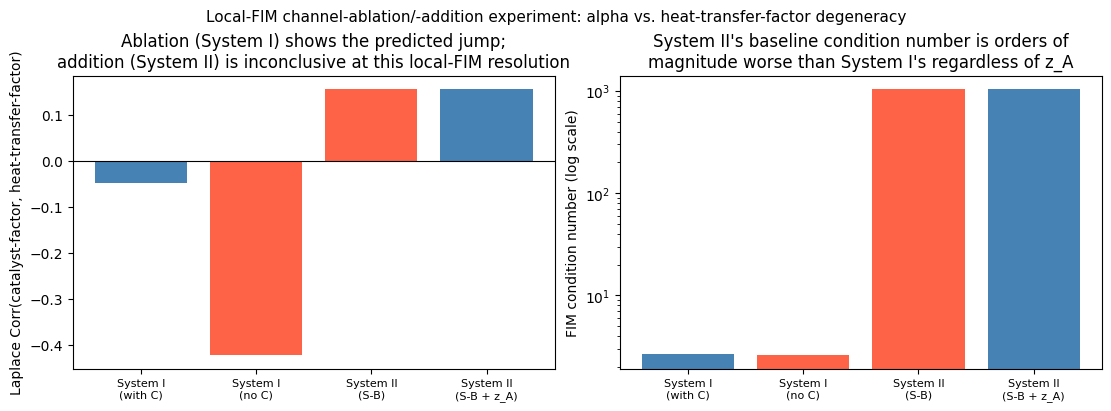

In [7]:
print(f"{'Representation':42s} {'Corr(a,b-type)':>15s} {'cond(FIM)':>12s}")
print(f"{'System I, full 29-D (with C)':42s} {corr_full:15.3f} {crb_full['cond']:12.2f}")
print(f"{'System I, no composition channel':42s} {corr_noc:15.3f} {crb_noc['cond']:12.2f}")
print(f"{'System II, standard S-B (66-D)':42s} {corr_std:15.3f} {crb_std['cond']:12.2e}")
print(f"{'System II, S-B + z_A analyzer (72-D)':42s} {corr_zA:15.3f} {crb_zA['cond']:12.2e}")

labels = ["System I\n(with C)", "System I\n(no C)", "System II\n(S-B)", "System II\n(S-B + z_A)"]
corrs = [corr_full, corr_noc, corr_std, corr_zA]
conds = [crb_full['cond'], crb_noc['cond'], crb_std['cond'], crb_zA['cond']]

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
colors = ["steelblue", "tomato", "tomato", "steelblue"]
axes[0].bar(labels, corrs, color=colors)
axes[0].axhline(0, color="k", lw=0.8)
axes[0].set_ylabel("Laplace Corr(catalyst-factor, heat-transfer-factor)")
axes[0].set_title("Ablation (System I) shows the predicted jump;\naddition (System II) is inconclusive at this local-FIM resolution")
axes[0].tick_params(axis='x', labelsize=8)

axes[1].bar(labels, conds, color=colors)
axes[1].set_yscale("log")
axes[1].set_ylabel("FIM condition number (log scale)")
axes[1].set_title("System II's baseline condition number is orders of\nmagnitude worse than System I's regardless of z_A")
axes[1].tick_params(axis='x', labelsize=8)

fig.suptitle("Local-FIM channel-ablation/-addition experiment: alpha vs. heat-transfer-factor degeneracy", fontsize=11)
fig.savefig(FIGS / "34_alpha_betar_banana_mechanism.png", dpi=120, bbox_inches="tight")
plt.show()


## 6. Implications for identifiability of failure modes vs. parameters

**For System II's own classification task, this confound is mostly benign.**
Both $\alpha$ (catalyst decay) and $\beta_r$ (jacket fouling) are reactor-unit
faults. The manuscript's hierarchical fault taxonomy only needs to answer
"which *unit* is degraded," and W11 is classified correctly as a reactor fault
in all 30 replicates (Section `sec:wu_identifiability`) *despite* the
$(\alpha,\beta_r)$ posterior living on an almost one-dimensional ridge — because
both ends of that ridge point to the same unit-level diagnosis. This contrasts
with Artefact 3 (`\alpha`-`z_{A0,\mathrm{eff}}`), which crosses the
reactor/feed unit boundary and *is* operationally severe (feed-fault F1 = 0.000)
even though its raw summary-level coupling magnitude is comparable.

**For root-cause attribution within the reactor unit, the confound is a real,
representation-driven limit — not resolvable just by better training.** Section
8.1 of the manuscript already shows the raw-trajectory FIM collapses this
coupling's normalised off-diagonal to ~0 (condition number 3,450 → 5.3): the
*information* needed to tell catalyst decay from jacket fouling is present in
the raw channel-level signal, just discarded by whole-window mean/std/slope
aggregation (which keeps the common level shift in $Q_j$ but throws away the
transient shape that distinguishes the two causes). A tuned EKF with raw-model
access can use that information; the amortised CNN-SBI posterior tested in the
manuscript could not (posterior correlation stayed above +0.99 even on raw
trajectories). Section 4 above suggests a second, independent candidate route to
the same information: a direct reactor-composition sensor plays exactly this
role, for free, in System I ($C$'s governing equation structurally excludes
$\beta$). The local-FIM check in Section 4b could not confirm that the same
addition would resolve $\alpha/\beta_r$ in System II — that diagnostic is
already known to be too insensitive for this purpose — so this remains a
structurally well-motivated but empirically open candidate, not a demonstrated
fix.

**The general lesson** (consistent with the manuscript's Artefact-1/2/3
framing, Section 8.1's closing paragraph): whether a given parameter confound
is a problem depends on (i) whether the confused parameters share a fault unit
in the decision taxonomy, and (ii) whether the chosen measurement set contains
a channel whose *governing equation* structurally excludes one of the two
parameters. System I happens to have such a channel for free ($C$, pre-existing
instrumentation); System II's S-B/S-A sensor suites do not, for $\alpha/\beta_r$
specifically (only for feed composition, where the already-implemented S-C
feed-line analyzer resolves the unrelated $\alpha/z_{A0,\mathrm{eff}}$ and
$\eta_\mathrm{col}/z_{A0,\mathrm{eff}}$ confounds). A reactor-side composition
analyzer is the natural, testable next instrumentation candidate if
within-reactor-unit attribution (catalyst vs. jacket) is ever operationally
required for System II, following the same feasibility-check protocol already
used for the feed-line analyzer (`notebooks/legacy_systemII/43_...ipynb`).

## 7. Summary

| | System I $(\alpha,\beta)$ | System II $(\alpha,\beta_r)$ |
|---|---|---|
| Shared masking mechanism (Loop 1 integral control) | Yes | Yes |
| Trained-posterior correlation, moderate combined fault | small (Sc4, see Section 2's live number) | **+0.998** (W11, reproduced live in Section 2) |
| Governing-equation structure | $\beta$ absent from $dC/dt$ | $\beta_r$ absent from $dz_A/dt$ |
| Composition channel in instrumentation | Yes ($C$) | **No** (S-A/S-B) |
| Correlation with composition channel removed (System I) / added (System II), local FIM | jumps up ~9× (confirmed) | unchanged (local-FIM diagnostic inconclusive — see Section 4b) |
| Operational consequence | n/a (not a real confound here) | Benign for unit-level diagnosis; blocks catalyst-vs-jacket attribution |

System II's $(\alpha,\beta_r)$ banana is not a deeper structural problem specific
to the recycle plant — the underlying physics is the same degeneracy risk System
I also carries, and System I avoids it only because it happens to retain a
reactor-composition sensor that Wu 2003's S-A/S-B instrumentation choice omits.
